# Example: West Claude University

Below is a fictional survey of fictional students from the fictional West Claude University. To reiterate, this is synthetic data produced using Claude.
 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
wcu_df = pd.read_csv('https://raw.githubusercontent.com/GettysburgDataScience/datasets/refs/heads/main/westclaudeuniversity_survey.csv')
wcu_df.head()

,student_id,gpa,year,major,credits,sleep_hrs,study_hrs,social_hrs,screen_hrs,mental_health_score,extracurriculars,extracurricular_hrs,has_minor,part_time_job,commuter,first_gen
0,WU0001,3.61,Senior,Other,15,7.7,17.1,0.0,3.6,4.0,1,3.8,0,0,0,0
1,WU0002,2.91,Junior,English,16,7.2,9.4,7.8,2.8,5.0,2,7.3,1,0,0,0
2,WU0003,3.42,Junior,Biology,16,6.2,21.0,4.4,5.6,4.0,0,0.0,0,0,0,0
3,WU0004,4.00,Junior,Other,16,7.7,32.6,7.4,5.2,6.0,2,7.3,0,0,0,0
4,WU0005,2.65,Sophomore,Biology,18,7.3,0.0,2.7,1.2,8.0,1,2.0,0,0,1,0


- Exploratory Data Analysis
- Data Cleaning
- Modeling
  - Feature Engineering/Feature Selection
  - train test split
  - feature scaling
  - model fit and selection
  - model assessment
- Intepretation

In [3]:
## EDA

wcu_df.info() # data types and missing data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           200 non-null    object 
 1   gpa                  200 non-null    float64
 2   year                 200 non-null    object 
 3   major                200 non-null    object 
 4   credits              200 non-null    int64  
 5   sleep_hrs            195 non-null    float64
 6   study_hrs            200 non-null    float64
 7   social_hrs           197 non-null    float64
 8   screen_hrs           193 non-null    float64
 9   mental_health_score  197 non-null    float64
 10  extracurriculars     200 non-null    int64  
 11  extracurricular_hrs  200 non-null    float64
 12  has_minor            200 non-null    int64  
 13  part_time_job        200 non-null    int64  
 14  commuter             200 non-null    int64  
 15  first_gen            200 non-null    int

In [4]:
wcu_df.describe() # descriptive stats

,gpa,credits,sleep_hrs,study_hrs,social_hrs,screen_hrs,mental_health_score,extracurriculars,extracurricular_hrs,has_minor,part_time_job,commuter,first_gen
count,200.000000,200.000000,195.000000,200.000000,197.000000,193.000000,197.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,2.956450,14.705000,6.700000,14.745500,8.727411,4.521244,5.609137,1.860000,4.660000,0.330000,0.335000,0.320000,0.285000
std,0.704551,2.265754,1.146038,8.404341,5.182000,2.014095,1.967729,1.396478,3.900921,0.471393,0.473175,0.467647,0.452547
min,1.080000,9.000000,3.000000,0.000000,0.000000,0.200000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.430000,13.000000,6.000000,9.250000,4.800000,3.000000,4.000000,1.000000,1.700000,0.000000,0.000000,0.000000,0.000000
50%,2.975000,15.000000,6.700000,14.750000,8.300000,4.500000,6.000000,2.000000,4.100000,0.000000,0.000000,0.000000,0.000000
75%,3.490000,16.000000,7.500000,20.550000,13.100000,5.900000,7.000000,3.000000,6.900000,1.000000,1.000000,1.000000,1.000000
max,4.000000,20.000000,9.200000,43.500000,22.800000,10.000000,10.000000,5.000000,14.800000,1.000000,1.000000,1.000000,1.000000


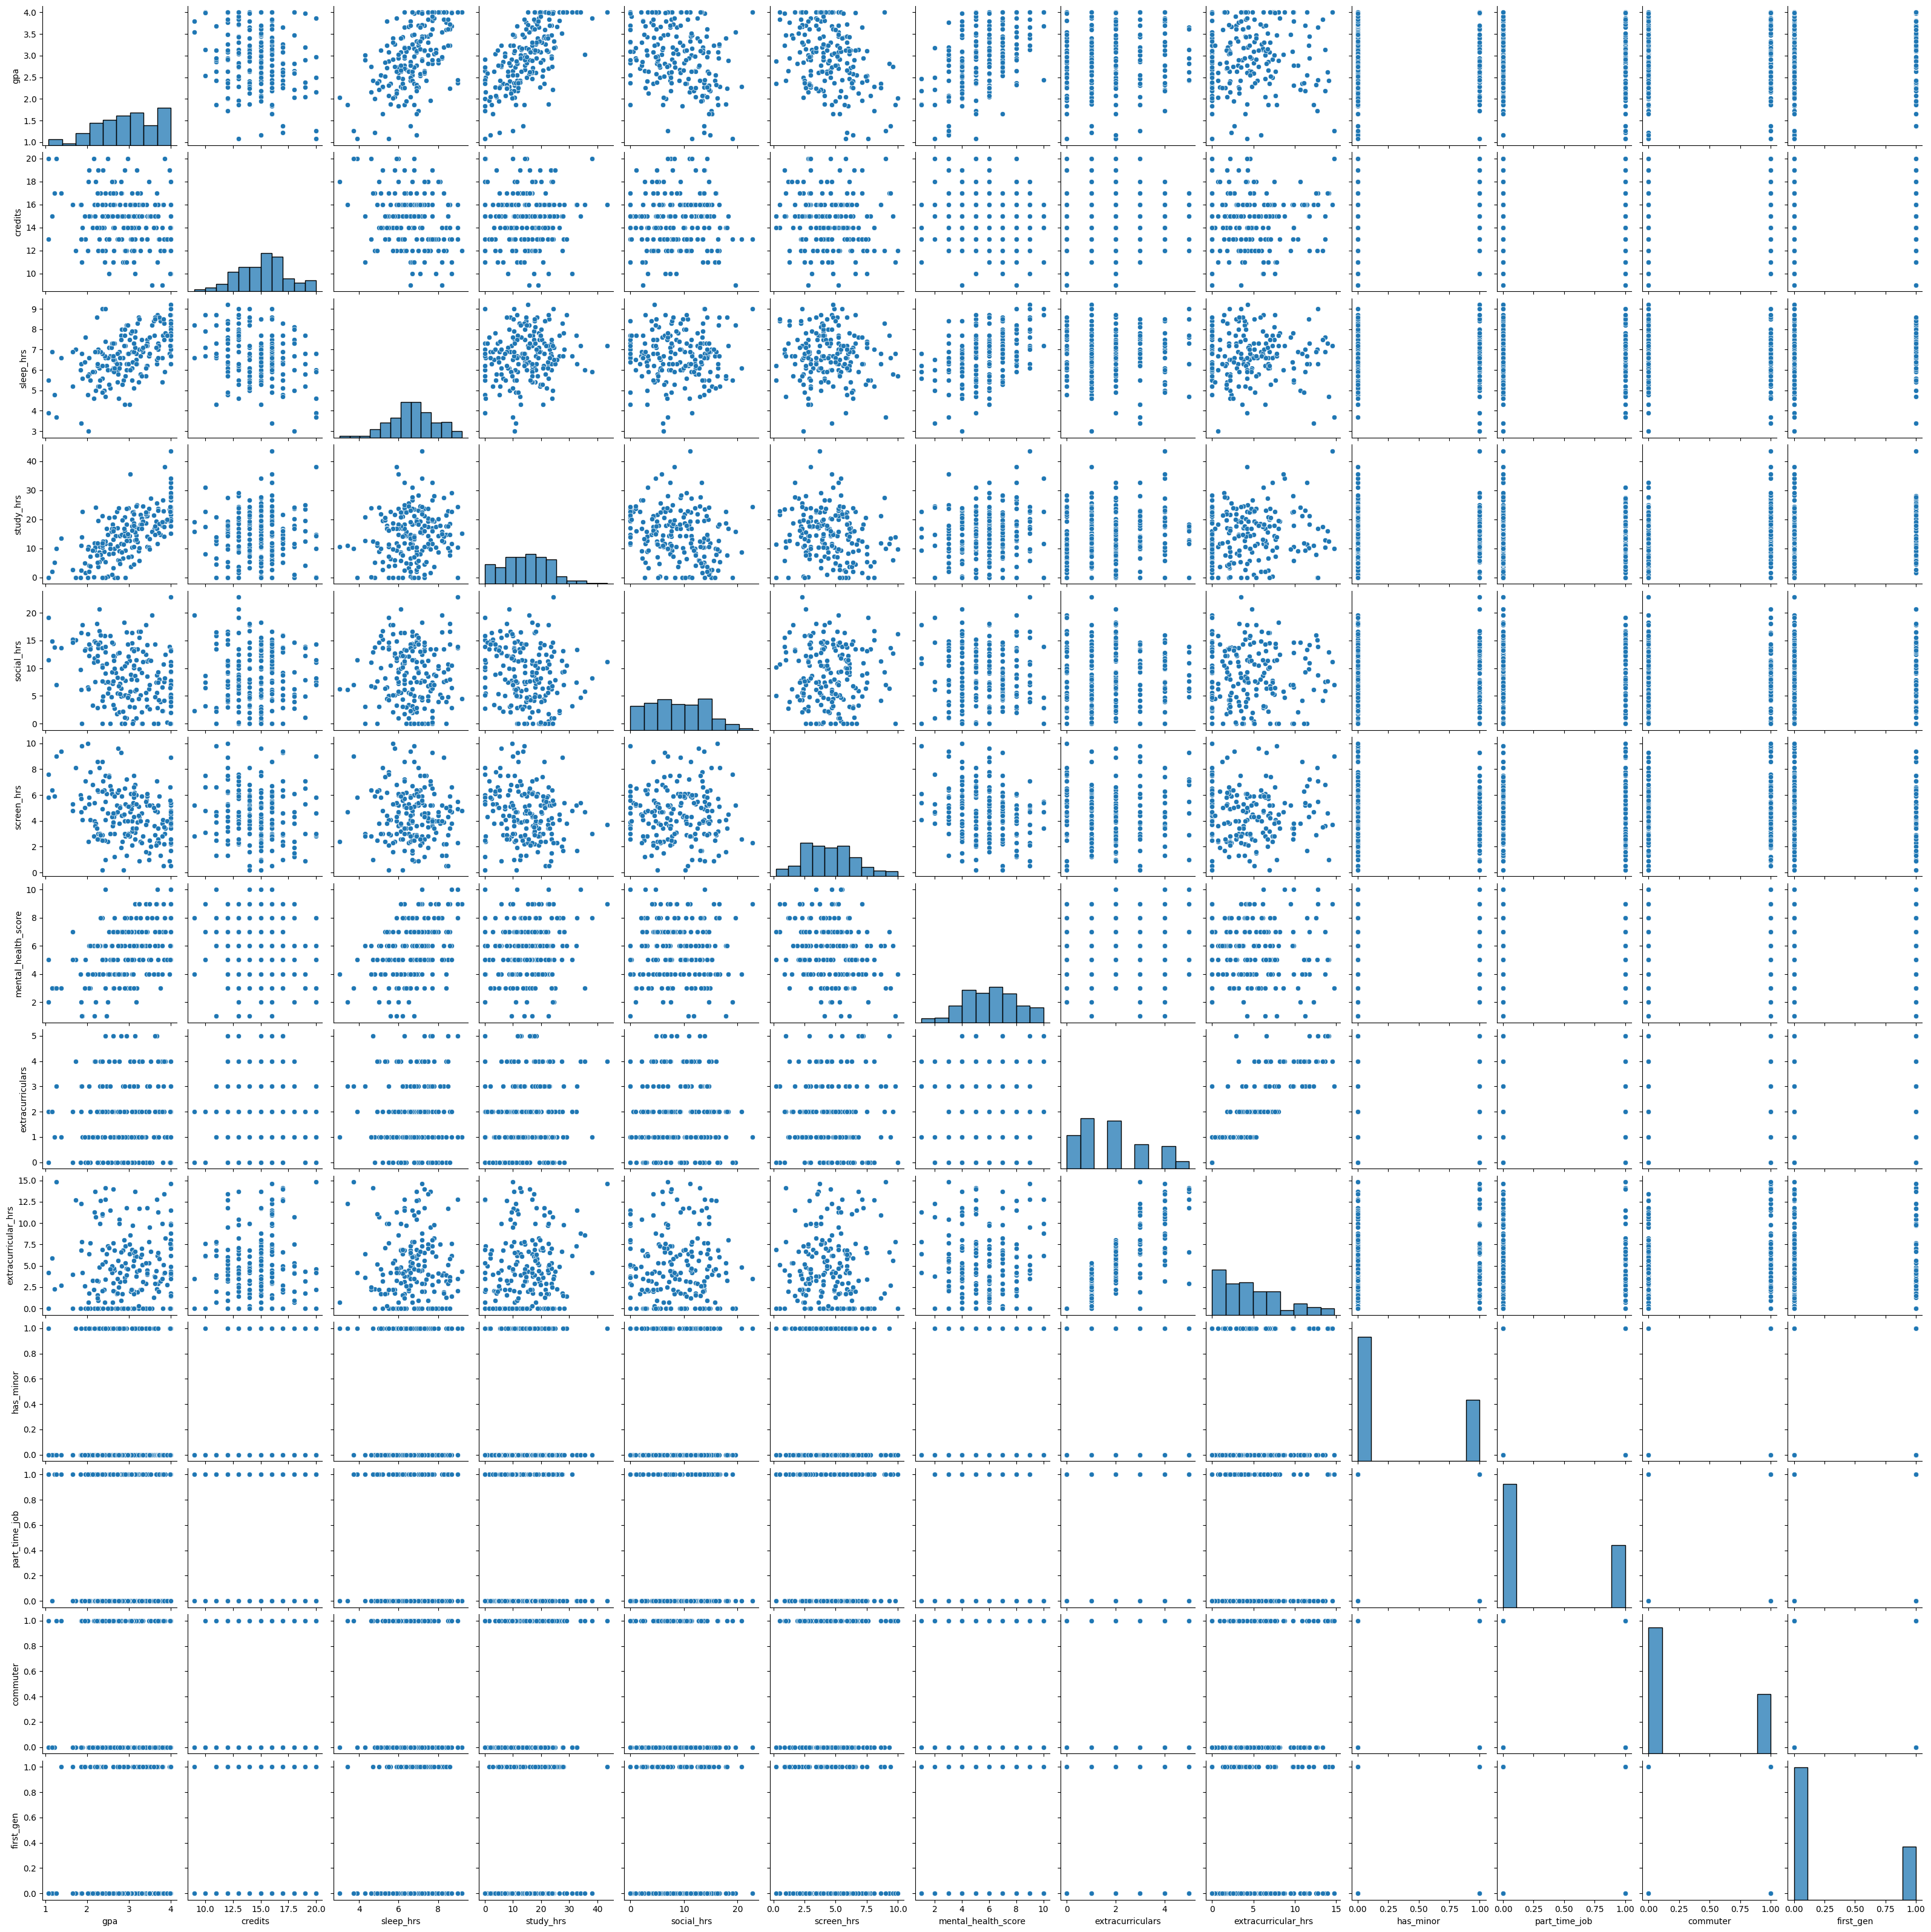

In [5]:
sns.pairplot(wcu_df)
plt.show()

In [6]:
wcu_df.drop(columns = 'student_id', inplace = True)

wcu_df.replace({'Freshman':1,
                'Sophomore': 2,
                'Junior': 3,
                'Senior':4},
               inplace = True)

wcu_df.dropna(inplace=True)

/var/folders/qm/g7x838zs775f4j_5s231csf80000gn/T/ipykernel_30484/3048183540.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  wcu_df.replace({'Freshman':1,


## Feature Engineering

 - One-hot encoding for majors using get dummies
 - Polynomial terms (maybe try interaction only?)

In [7]:
wcu_df['major'].unique()
majors_df = pd.get_dummies(wcu_df['major'], dtype = int)

In [8]:
wcu_df = wcu_df.drop(columns = 'major').join(majors_df)

In [9]:
# First, let's finally separate the target from the features
# We could have done this earlier, even at the very beginning

target = 'gpa'
y = wcu_df[target]
X = wcu_df.drop(columns = target)

X.info()


<class 'pandas.core.frame.DataFrame'>
Index: 183 entries, 0 to 199
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 183 non-null    int64  
 1   credits              183 non-null    int64  
 2   sleep_hrs            183 non-null    float64
 3   study_hrs            183 non-null    float64
 4   social_hrs           183 non-null    float64
 5   screen_hrs           183 non-null    float64
 6   mental_health_score  183 non-null    float64
 7   extracurriculars     183 non-null    int64  
 8   extracurricular_hrs  183 non-null    float64
 9   has_minor            183 non-null    int64  
 10  part_time_job        183 non-null    int64  
 11  commuter             183 non-null    int64  
 12  first_gen            183 non-null    int64  
 13  Biology              183 non-null    int64  
 14  CS                   183 non-null    int64  
 15  Economics            183 non-null    int64  


In [16]:
# Make Polynomial Terms
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split

In [12]:
pf = PolynomialFeatures(degree=2, include_bias = False)
Xpoly = pf.fit_transform(X)

feature_names = pf.get_feature_names_out()

X_df = pd.DataFrame(data = Xpoly, columns = feature_names)
X_df

,year,credits,sleep_hrs,study_hrs,social_hrs,screen_hrs,mental_health_score,extracurriculars,extracurricular_hrs,has_minor,...,English^2,English Other,English Psychology,English Undecided,Other^2,Other Psychology,Other Undecided,Psychology^2,Psychology Undecided,Undecided^2
0,4.0,15.0,7.7,17.1,0.0,3.6,4.0,1.0,3.8,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,3.0,16.0,7.2,9.4,7.8,2.8,5.0,2.0,7.3,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,16.0,6.2,21.0,4.4,5.6,4.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3.0,16.0,7.7,32.6,7.4,5.2,6.0,2.0,7.3,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,2.0,18.0,7.3,0.0,2.7,1.2,8.0,1.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,1.0,16.0,6.6,4.7,5.4,5.0,4.0,2.0,4.2,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
179,1.0,15.0,6.4,4.9,13.2,5.0,3.0,1.0,2.6,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
180,3.0,10.0,8.7,22.6,6.5,6.6,5.0,2.0,7.6,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
181,3.0,13.0,4.6,23.9,6.8,6.4,4.0,1.0,2.5,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [20]:
X_train, X_test, y_train, y_test = train_test_split(Xpoly, y, test_size = 0.2)
ss = StandardScaler()

Z_train = ss.fit_transform(X_train)
Z_test = ss.transform(X_test)

In [75]:
def display_coef(models, features, sort_abs = True):
    if sort_abs:
        idx = np.argsort(np.abs(models[0].coef_))[::-1]
    else:
        idx = np.argsort(models[0].coef_)[::-1]

    f_width = np.array([len(f) for f in feature_names]).max() + 5
    for f, c in zip(features[idx], models[0].coef_[idx]):
        print(f'{f:<40}{c:+0.4f}')

In [74]:
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV, ElasticNetCV

linreg = LinearRegression()
linreg.fit(X_train, y_train)

linreg.coef_.shape

display_coef([linreg], feature_names)

part_time_job CS              +0.3175
screen_hrs                    +0.2900
has_minor Other               +0.2879
screen_hrs Undecided          -0.2793
has_minor Psychology          -0.2649
commuter Psychology           -0.2605
first_gen Other               -0.2579
has_minor part_time_job       +0.2454
screen_hrs Psychology         +0.2443
year Other                    -0.2425
year CS                       -0.2366
commuter Biology              +0.2267
year English                  +0.2236
extracurriculars CS           +0.2169
part_time_job English         +0.2076
sleep_hrs Other               +0.2036
commuter Undecided            +0.2023
sleep_hrs has_minor           +0.1882
part_time_job Economics       -0.1758
first_gen Economics           +0.1739
sleep_hrs CS                  +0.1673
year extracurriculars         +0.1640
extracurriculars English      +0.1590
extracurriculars Psychology   -0.1576
extracurriculars Undecided    -0.1515
extracurriculars first_gen    +0.1513
sleep_hrs En

In [48]:
linreg.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'n_features_in_': 230,
 'coef_': array([-0.04785981, -0.05977542,  0.07824846, -0.0213725 , -0.03318429,
         0.29001914, -0.03473633, -0.00640091,  0.0495813 , -0.07015744,
        -0.00252562, -0.12771171,  0.00706277, -0.05259352,  0.0652834 ,
         0.004901  , -0.00320132,  0.11937871, -0.13571417,  0.0019459 ,
         0.03857183, -0.0368391 , -0.02529963,  0.01445224,  0.01508435,
        -0.01845853,  0.02380923,  0.16403642, -0.02790199, -0.08469896,
        -0.08359401, -0.03835715, -0.02067386,  0.0190684 , -0.23655901,
         0.08155677,  0.22359067, -0.24248179, -0.02007678,  0.12704192,
         0.00237383,  0.01201703,  0.00553631,  0.00226461, -0.00191464,
        -0.002145  , -0.06849679,  0.01523293, -0.01865188,  0.03458881,
         0.00499792, -0.01207818,  0.01231499, -0.05047579, -0.05072986,
        -0.05764918, -0.00960283,  0.01292843,  0.08343882,  0.04458725

In [46]:
y_linreg_train = linreg.predict(X_train)
y_linreg_test = linreg.predict(X_test)

In [ ]:
alpha_test = np.logspace(-3,3,25)
l1_test = np.linspace(0,1.001,0.2)

ridge = RidgeCV(alphas = alpha_test)
ridge.fit(X_train, y_train)

lasso = LassoCV(alphas = alpha_test)
lasso.fit(X_train, y_train)

elastic = ElasticNetCV(l1_ratio = l1_test, alphas = alpha_test)